# House Price Prediction

## Summary of the key steps taken in the notebook
1. Data Loading and Initial Exploration: The housing.csv dataset was loaded into a pandas DataFrame. Initial information about the data, including column types and non-null counts, was displayed using data.info().
2. Data Cleaning: Rows with missing values in the total_bedrooms column were removed using data.dropna().
Data Splitting: The data was split into features (X) and the target variable (y), which is median_house_value. Then, the data was further split into training and testing sets using train_test_split.
3. Exploratory Data Analysis (EDA): Histograms of the training data were generated to visualize the distribution of numerical features. A heatmap was created to visualize the correlation matrix between the features, including the one-hot encoded ocean_proximity column and the target variable.
4. Feature Engineering: New features, bedroom_ratio (ratio of total bedrooms to total rooms) and household_rooms (average number of rooms per household), were created to potentially improve model performance. Logarithmic transformations were applied to some numerical features to handle skewed distributions.
5. Categorical Feature Encoding: The ocean_proximity categorical column was converted into numerical format using one-hot encoding (pd.get_dummies).
6. Model Training: A RandomForestRegressor model was initialized and trained on the processed training data (X_train, y_train).
7. Model Evaluation: The trained model's performance was evaluated on the testing data (X_test, y_test) using the score() method, which for regressors typically returns the R-squared value.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data = pd.read_csv('housing.csv')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
data.dropna(inplace=True)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


We can cleary observe that NaN values have been dropped

In [11]:
from sklearn.model_selection import train_test_split

X = data.drop('median_house_value', axis=1)
y = data['median_house_value']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16346, 9)
(4087, 9)
(16346,)
(4087,)


In [14]:
train_data = X_train.join(y_train)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

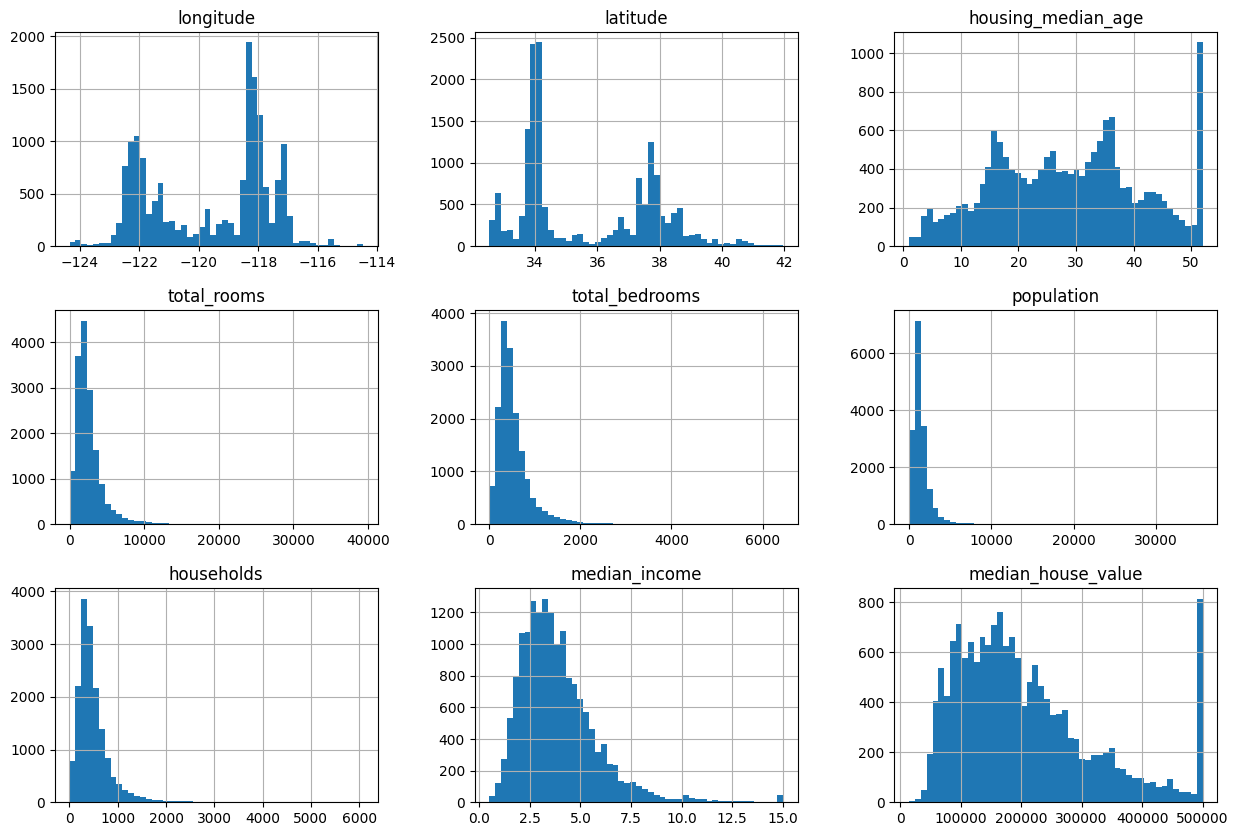

In [15]:
train_data.hist(figsize=(15,10), bins=50)

<Axes: >

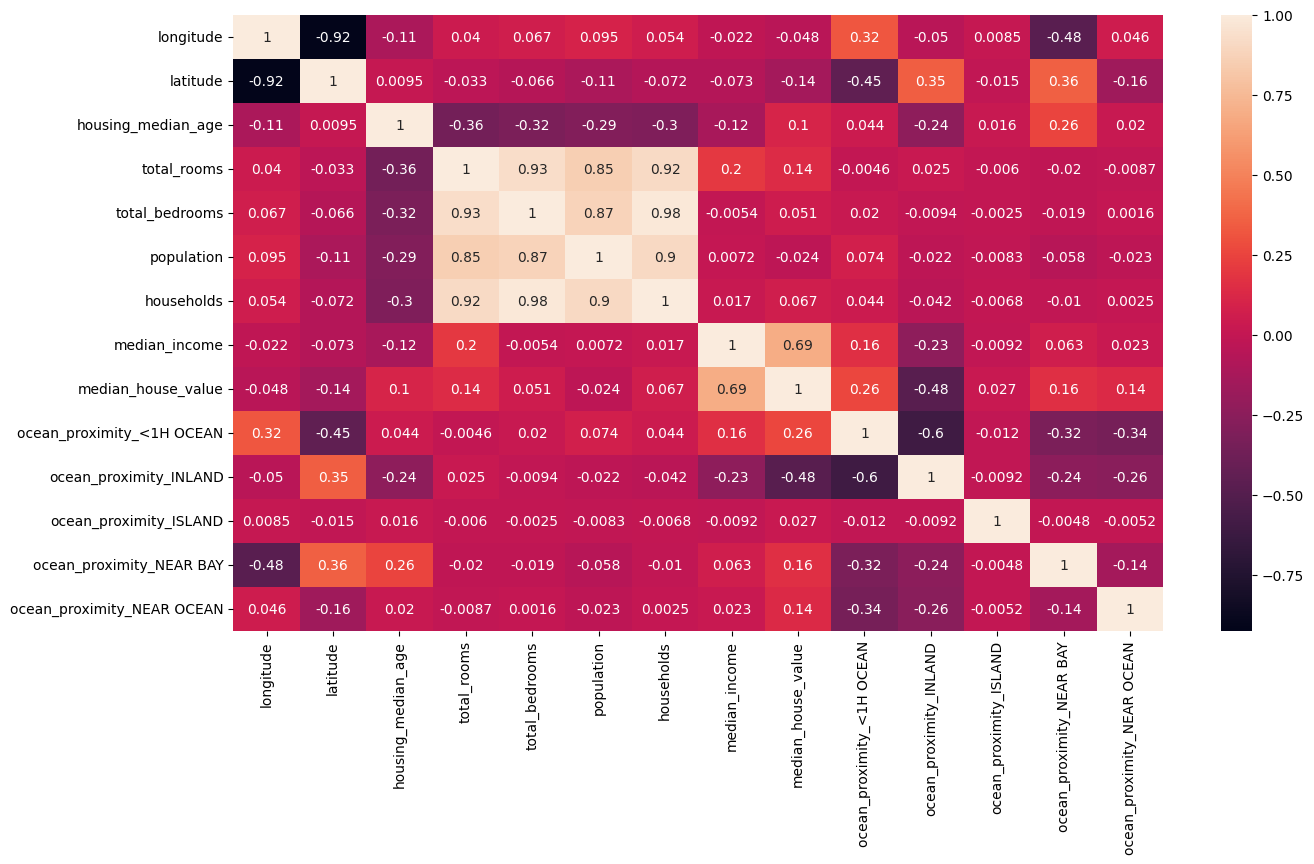

In [16]:
plt.figure(figsize=(15,8))
# Apply one-hot encoding to the 'ocean_proximity' column
train_data_encoded = pd.get_dummies(train_data, columns=['ocean_proximity'])
sns.heatmap(train_data_encoded.corr(), annot=True)

In [17]:
# Recreate train_data from X_train and y_train
train_data = X_train.join(y_train)

# Apply logarithmic transformation to numerical columns
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

# Apply one-hot encoding to the 'ocean_proximity' column and join back
train_data = train_data.join(pd.get_dummies(train_data['ocean_proximity'])).drop('ocean_proximity', axis=1)

The code one-hot encodes the 'ocean_proximity' column. pd.get_dummies creates binary columns for each category. train_data.join adds these to the DataFrame. .drop removes the original column. This converts categorical data for model use.

In [18]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
17727,-121.80,37.32,14.0,8.392310,6.829794,7.900637,6.793466,4.7027,227600.0,True,False,False,False,False
2057,-119.63,36.64,33.0,6.944087,5.204007,6.431331,5.164786,3.4107,110400.0,False,True,False,False,False
6453,-118.06,34.12,25.0,8.266678,6.744059,7.522400,6.633318,3.6639,248100.0,False,True,False,False,False
4619,-118.31,34.07,28.0,7.767687,6.856462,7.922986,6.796824,2.2364,305600.0,True,False,False,False,False
15266,-117.27,33.04,27.0,7.517521,5.973810,7.172425,6.003887,3.5500,214600.0,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11397,-117.97,33.72,24.0,8.003697,6.216606,7.271009,6.118097,5.4286,273400.0,True,False,False,False,False
12081,-117.54,33.76,5.0,8.673684,6.943122,8.089176,6.909753,4.7965,160800.0,True,False,False,False,False
5447,-118.42,34.01,42.0,7.374629,5.913503,6.859615,5.894403,3.0990,335400.0,True,False,False,False,False
866,-122.04,37.57,12.0,8.651724,6.970730,8.142354,6.964136,5.2879,231200.0,False,False,False,True,False


<Axes: >

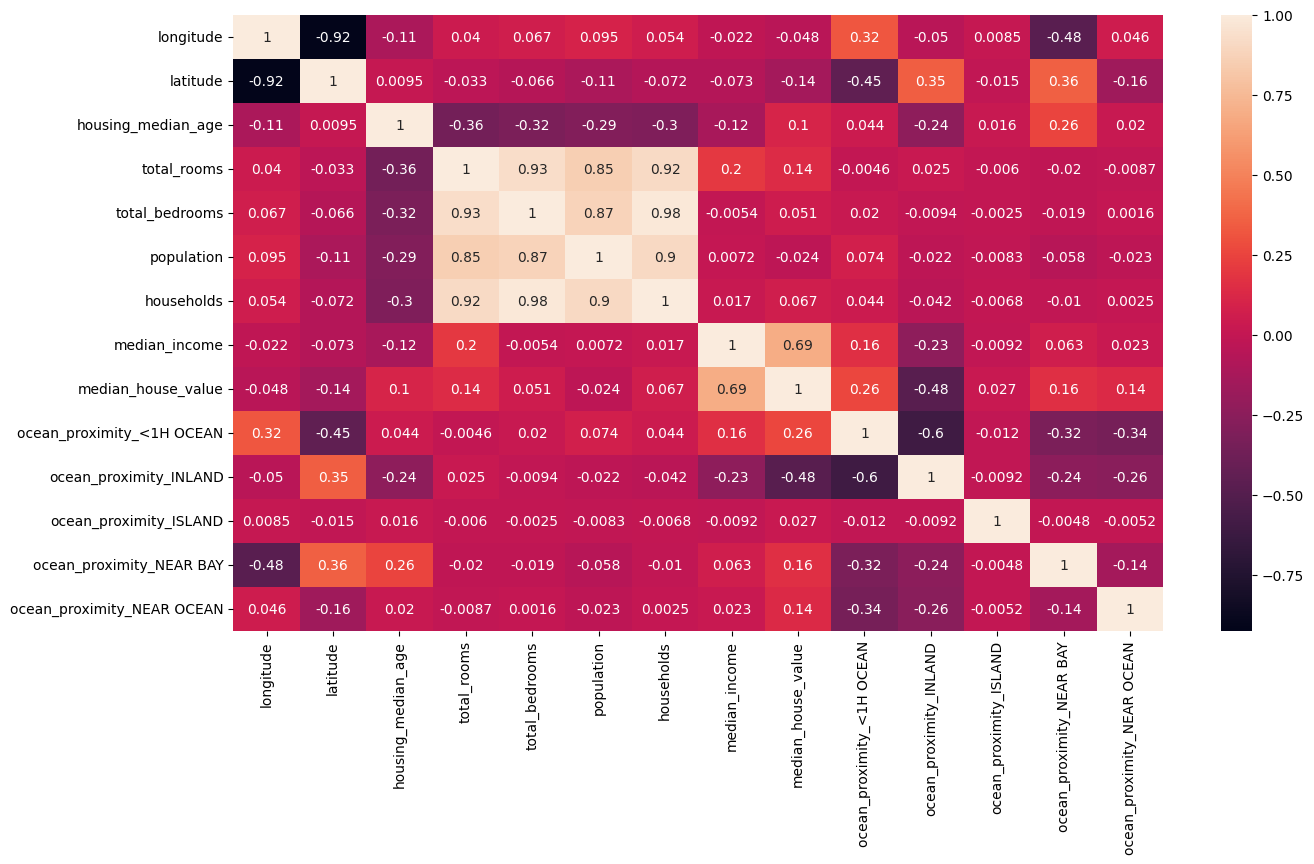

In [19]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data_encoded.corr(), annot=True)

In [20]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']

<Axes: >

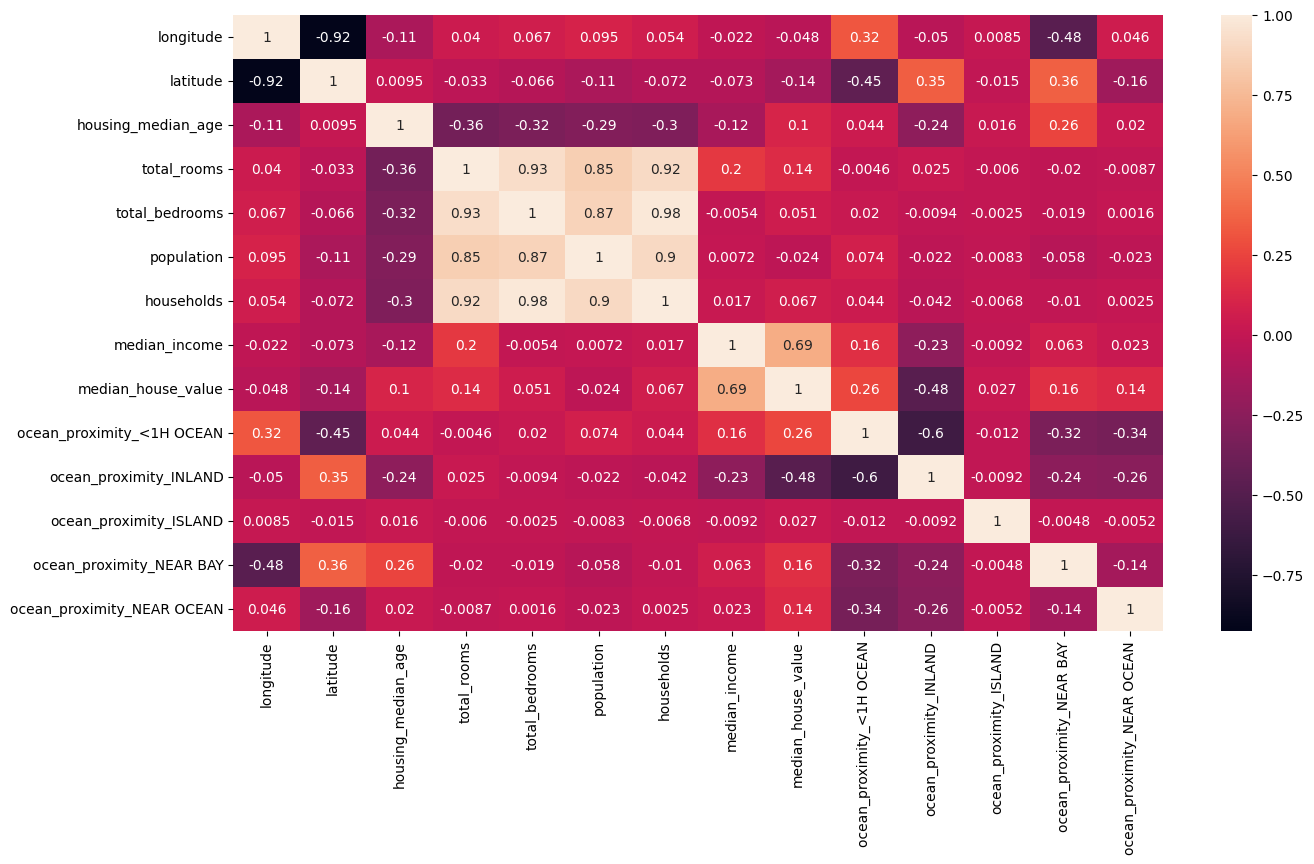

In [21]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data_encoded.corr(), annot=True)

In [22]:
test_data = X_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = test_data.join(pd.get_dummies(test_data['ocean_proximity'])).drop('ocean_proximity', axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']

In [23]:
X_train,y_train = train_data.drop('median_house_value', axis=1), train_data['median_house_value']
X_test,y_test = test_data.drop('median_house_value', axis=1), test_data['median_house_value']

In [24]:
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor()

regressor.fit(X_train, y_train)

RandomForestRegressor()

In [25]:
regressor.score(X_test,y_test)

0.8196262275336124